#### 1. SIR
Це базова модель без урахування демографії (народжуваності/смертності).

**Змінні:**
*   $S(t)$ (Susceptible) — кількість сприйнятливих до хвороби.
*   $I(t)$ (Infected) — кількість інфікованих.
*   $R(t)$ (Recovered) — кількість одужалих (з імунітетом).
*   $N$ — загальна чисельність ($N = S + I + R = const$).

**Система рівнянь:**
$$
\begin{cases}
\frac{dS}{dt} = -\beta \frac{S I}{N} \\
\frac{dI}{dt} = \beta \frac{S I}{N} - \gamma I \\
\frac{dR}{dt} = \gamma I
\end{cases}
$$

**Фізичний зміст коефіцієнтів:**
*   $\beta$ (betta) — коефіцієнт інтенсивності контактів (швидкість зараження). Член $\beta \frac{S I}{N}$ показує кількість нових заражень за одиницю часу.
*   $\gamma$ (gamma) — коефіцієнт одужання. Величина $1/\gamma$ — це середня тривалість хвороби.

---

#### 2. Модель SIV
Ця модель складніша, оскільки враховує народження, смертність, вакцинацію та втрату імунітету.

**Змінні:**
*   $S(t)$ — сприйнятливі.
*   $I(t)$ — інфіковані.
*   $V(t)$ (Vaccinated) — вакциновані (мають тимчасовий імунітет).

**Система рівнянь:**
$$
\begin{cases}
\frac{dS}{dt} = (1-q)A - \beta S I - (p + d)S + \gamma I + \epsilon V \\
\frac{dI}{dt} = \beta S I - (d + \alpha + \gamma)I \\
\frac{dV}{dt} = q A + p S - (\epsilon + d)V
\end{cases}
$$

**Фізичний зміст параметрів:**
*   **Приріст населення:**
    *   $A$ — загальна кількість новонароджених за одиницю часу.
    *   $q$ — частка новонароджених, які одразу отримують вакцину (група $V$).
    *   $(1-q)$ — частка новонароджених, які потрапляють у групу ризику ($S$).
*   **Смертність:**
    *   $d$ — коефіцієнт природної смертності (для всіх груп).
    *   $\alpha$ (alpha) — додаткова смертність саме від хвороби (тільки для групи $I$).
*   **Переходи:**
    *   $\beta$ (betta) — швидкість зараження ($S \to I$).
    *   $p$ — вакцинація сприйнятливих ($S \to V$).
    *   $\epsilon$ (eps) — втрата імунітету вакцини ($V \to S$).
    *   $\gamma$ (gamma) — одужання.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from matplotlib.colors import ListedColormap
from matplotlib import animation
from IPython.display import HTML

In [2]:
def method_rk4(func, y0, time_arr):
    history = np.zeros((len(time_arr), len(y0)))
    history[0] = y0
    for i in range(len(time_arr) - 1):
        h = time_arr[i+1] - time_arr[i]
        y_curr = history[i]
        
        k1 = func(y_curr)
        k2 = func(y_curr + 0.5 * h * k1)
        k3 = func(y_curr + 0.5 * h * k2)
        k4 = func(y_curr + h * k3)
        
        history[i+1] = y_curr + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return history

In [3]:
# SIR модель
I0 = 2100        # Початкові інфіковані
R0 = 2500        # Початкові одужали
S0 = 45400       # Початкові сприйнятливі
N = S0 + I0 + R0  # Загальна популяція

# Коефіцієнти (підібрані для демонстрації графіків як у методичці)
beta = 0.5       # Швидкість зараження
gamma = 0.1      # Швидкість одужання

# Часові параметри
T_MAX = 30.0
dt = 0.1  # Крок інтегрування
time = np.arange(0, T_MAX + dt, dt)

y0 = S0, I0, R0

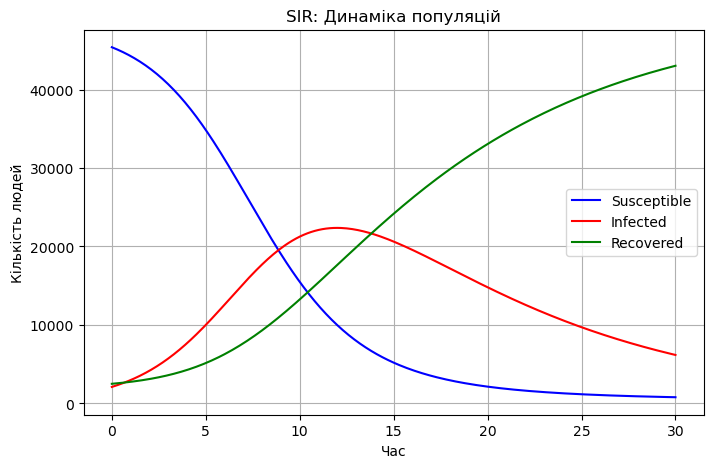

In [ ]:
def deriv_SIR(y):
    S, I, R = y
    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I
    dR = gamma * I
    return np.array([dS, dI, dR])

# Розв'язок системи
sir_rk4 = method_rk4(deriv_SIR, [S0, I0, R0], time)
S = sir_rk4[:, 0]
I = sir_rk4[:, 1]
R = sir_rk4[:, 2]

# Візуалізація
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(time, S, label='Susceptible', color='blue')
ax.plot(time, I, label='Infected', color='red')
ax.plot(time, R, label='Recovered', color='green')

ax.set_title('SIR: Динаміка популяцій')
ax.set_xlabel('Час')
ax.set_ylabel('Кількість людей')
ax.grid()
ax.legend()

plt.show()


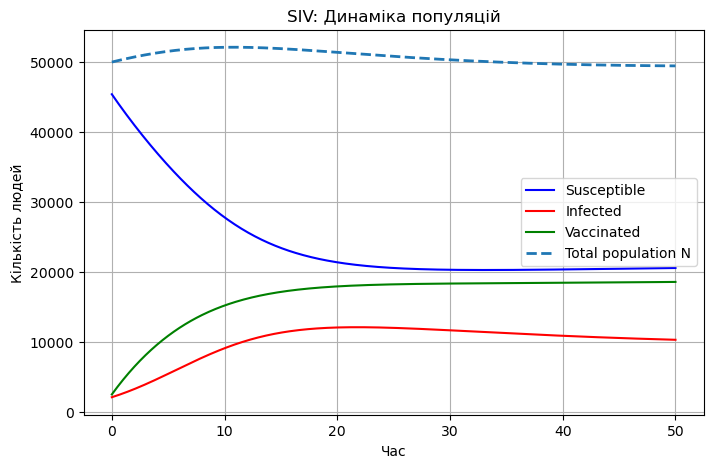

In [ ]:
# --- ПАРАМЕТРИ МОДЕЛІ SIV ---
# Початкові умови
S0 = 45400.0
I0 = 2100.0
V0 = 2500.0

# Коефіцієнти
A = 1000.0        # Приріст населення (народжуваність)
q = 0.1           # Частка новонароджених, які одразу вакциновані
beta = 0.00001    # Коефіцієнт зараження 
p = 0.05          # Коефіцієнт вакцинації сприйнятливих
d = 0.01          # Природна смертність
gamma = 0.15      # Швидкість одужання (повернення в S, це особливість SIS)
eps = 0.05        # Швидкість втрати імунітету вакцини (V -> S)
alpha = 0.05      # Смертність від хвороби

# Часові параметри
T_MAX = 50.0
dt = 0.1
time = np.arange(0, T_MAX + dt, dt)

y0 = [S0, I0, V0]

# --- ФУНКЦІЯ ПОХІДНИХ SIV ---
def deriv_SIV(y):
    S, I, V = y
    dS = (1-q)*A - beta*S*I - (p + d)*S + gamma*I + eps*V
    dI = beta*S*I - (d + alpha + gamma)*I
    dV = q*A + p*S - (eps + d)*V
    
    return np.array([dS, dI, dV])

# --- РОЗРАХУНОК ---
siv_rk4 = method_rk4(deriv_SIV, y0, time)

S = siv_rk4[:, 0]
I = siv_rk4[:, 1]
V = siv_rk4[:, 2]

N = S + I + V

# Візуалізація
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(time, S, label='Susceptible', color='blue')
ax.plot(time, I, label='Infected', color='red')
ax.plot(time, V, label='Vaccinated', color='green')
ax.plot(time, N, label='Total population N', linestyle='--', linewidth=2)

ax.set_title('SIV: Динаміка популяцій')
ax.set_xlabel('Час')
ax.set_ylabel('Кількість людей')
ax.grid()
ax.legend()
plt.show()

# Частина 2

In [6]:
# Налаштування кольорів: Сірий (S), Червоний (I), Зелений (R)
cmap = ListedColormap(["#D3D3D3", "#FF2D00", "#4CAF50"])

SUSCEPTIBLE = 0
INFECTED = 1
RECOVERED = 2

KERNEL_8 = np.array([[1, 1, 1],
                     [1, 0, 1],
                     [1, 1, 1]])

def sir_step(grid, beta=0.3, gamma=0.1):
    # 1. Рахуємо інфікованих сусідів
    infected_mask = (grid == INFECTED).astype(int)
    infected_neighbors = convolve2d(infected_mask, KERNEL_8, mode='same')
    
    new_grid = grid.copy()
    
    # 2. Перехід S -> I (Ймовірнісний підхід)
    susceptible = (grid == SUSCEPTIBLE)
    # Формула: ймовірність не заразитись від k сусідів = (1-beta)^k
    # Отже ймовірність заразитись = 1 - (1-beta)^k
    p_infect = 1 - (1 - beta) ** infected_neighbors
    
    rand_inf = np.random.rand(*grid.shape)
    # Заражаємо тих, хто S, і де випала ймовірність
    new_infected = susceptible & (rand_inf < p_infect)
    new_grid[new_infected] = INFECTED
    
    # 3. Перехід I -> R (Ймовірнісний підхід)
    infected = (grid == INFECTED)
    rand_rec = np.random.rand(*grid.shape)
    new_recovered = infected & (rand_rec < gamma)
    new_grid[new_recovered] = RECOVERED
    
    return new_grid

def init_grid(n=100, initial_infected_fraction=0.01):
    grid = np.zeros((n, n), dtype=int)
    num_initial = int(n * n * initial_infected_fraction)
    idx = np.random.choice(n * n, num_initial, replace=False)
    grid.flat[idx] = INFECTED
    return grid

# --- Функція для збору статистики (Завдання 7) ---
def run(steps=100, n=100, beta=0.3, gamma=0.1):
    grid = init_grid(n, 0.01)
    
    history_S = []
    history_I = []
    history_R = []
    
    grids = [] # Для анімації
    
    for _ in range(steps):
        grids.append(grid.copy())
        
        # Рахуємо статистику
        unique, counts = np.unique(grid, return_counts=True)
        stats = dict(zip(unique, counts))
        history_S.append(stats.get(SUSCEPTIBLE, 0))
        history_I.append(stats.get(INFECTED, 0))
        history_R.append(stats.get(RECOVERED, 0))
        
        grid = sir_step(grid, beta, gamma)
        
    return grids, history_S, history_I, history_R

In [7]:
# === ЗАПУСК ===
steps = 170
n_size = 100

grids, S, I, R = run(steps=steps, n=n_size, beta=0.5, gamma=0.06)

# --- 1. Побудова анімації ---
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(grids[0], vmin=0, vmax=2, cmap=cmap)
ax.axis('off')
ax.set_title("Стохастична модель SIR")

def animate(frame):
    img.set_data(grids[frame])
    return [img]

ani = animation.FuncAnimation(fig, animate, frames=len(grids), blit=True)
plt.close() # Щоб не дублювати картинку

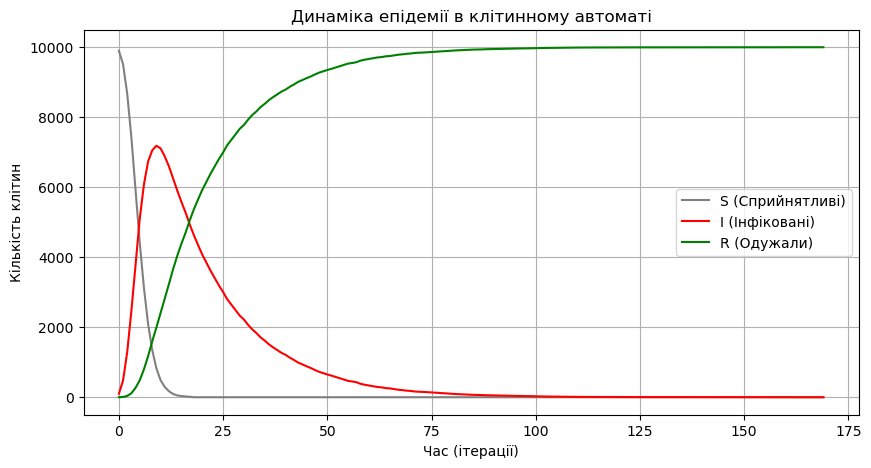

In [8]:
# --- 2. Побудова графіків (Завдання 7) ---
plt.figure(figsize=(10, 5))
time = range(steps)
plt.plot(time, S, label='S (Сприйнятливі)', color='gray')
plt.plot(time, I, label='I (Інфіковані)', color='red')
plt.plot(time, R, label='R (Одужали)', color='green')
plt.xlabel('Час (ітерації)')
plt.ylabel('Кількість клітин')
plt.title('Динаміка епідемії в клітинному автоматі')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Відображення анімації
HTML(ani.to_jshtml())